<a href="https://colab.research.google.com/github/juancarloszuletacorcho-ops/Juan.Zuleta/blob/main/Caso_Practico_2_Solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso Práctico Unidad 2 — Análisis de Sentimiento y Representaciones de Texto

**Autor:** Juan Carlos Zuleta  
**Asignatura:** Procesamiento del Lenguaje Natural (NLP)  
**Institución:** Asturias Corporación Universitaria

---

Este *notebook* desarrolla de forma reproducible las dos partes del caso práctico:

- **Parte 1 — Exploración y visualización de representaciones de texto:** Bolsa de Palabras (BoW), TF-IDF, *Word Embeddings* con Word2Vec y *embeddings* contextuales con *Sentence Transformers*, con visualización mediante Plotly.
- **Parte 2 — Clasificador de sentimientos con RNN:** preparación del conjunto IMDB, entrenamiento de una **LSTM** en PyTorch y evaluación del modelo.

> **Nota metodológica:** el código incluye fijación de semillas, separación estricta entre entrenamiento y prueba (el vocabulario se construye **solo** con el conjunto de entrenamiento para evitar fuga de datos) y métricas de evaluación completas (exactitud, precisión, *recall*, F1 y matriz de confusión).

## 0. Instalación de librerías

En Google Colab, ejecute esta celda una sola vez. Tras la instalación puede que Colab solicite reiniciar el entorno de ejecución.

In [13]:
# Instalación de las dependencias del caso práctico
!pip install -q pandas scikit-learn gensim plotly
!pip install -q -U sentence-transformers
# torch viene preinstalado en Colab; se incluye por completitud:
!pip install -q torch
print("Librerías instaladas correctamente.")

Librerías instaladas correctamente.


## 1. Carga de los archivos de datos

Se cargan los dos conjuntos de datos del caso (`IMDB_Dataset.csv` y `amazon_reviews.csv`).

In [14]:
# Carga de archivos en Google Colab (con respaldo para ejecución local)
import os

ARCHIVOS = ['IMDB_Dataset.csv', 'amazon_reviews.csv']

faltan = [f for f in ARCHIVOS if not os.path.exists(f)]
if faltan:
    try:
        from google.colab import files
        print("Por favor, suba los archivos:", faltan)
        subidos = files.upload()   # seleccione IMDB_Dataset.csv y amazon_reviews.csv
    except ModuleNotFoundError:
        print("No se está en Colab. Coloque los CSV en el mismo directorio que este notebook.")

# Verificación
for f in ARCHIVOS:
    print(f"{f}: {'ENCONTRADO' if os.path.exists(f) else 'FALTANTE'}")

Por favor, suba los archivos: ['IMDB_Dataset.csv']


Saving amazon_reviews.csv to amazon_reviews (1).csv
Saving IMDB Dataset.csv to IMDB Dataset (1).csv
IMDB_Dataset.csv: FALTANTE
amazon_reviews.csv: ENCONTRADO


# Parte 1 — Exploración y Visualización de Representaciones de Texto

## 1.1 Introducción a la representación de texto

Los algoritmos de aprendizaje automático no operan sobre texto en bruto, sino sobre vectores numéricos. El proceso de **vectorización** convierte cada documento en un vector dentro de un espacio de características. Exploraremos dos familias:

1. **Representaciones basadas en frecuencia** (*Bag of Words* y TF-IDF): cuentan o ponderan la aparición de términos. Son dispersas, de alta dimensión y no capturan el significado ni el orden de las palabras.
2. **Representaciones distribucionales** (Word2Vec y *Sentence Transformers*): vectores densos de baja dimensión que sitúan palabras o frases con significado similar en posiciones cercanas del espacio, siguiendo la hipótesis distribucional de Harris (*"una palabra se caracteriza por la compañía que mantiene"*).

### Importación de librerías de la Parte 1

In [15]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
import plotly.express as px

np.random.seed(42)

### Lectura y limpieza del conjunto IMDB

El conjunto `IMDB_Dataset.csv` contiene **50.000 reseñas** de películas etiquetadas como `positive` o `negative` (perfectamente balanceado: 25.000 / 25.000). Para la exploración de la Parte 1 trabajamos con una muestra de 5.000 reseñas (igual que el *notebook* guía), lo cual es suficiente para ilustrar las representaciones y mantiene la ejecución ágil.

## 1.2 Representaciones basadas en frecuencia

### Bolsa de Palabras (Bag of Words)

La Bolsa de Palabras representa cada documento como un vector con la **frecuencia** de cada término del vocabulario, ignorando el orden. Limitamos el vocabulario a las 1.000 palabras más frecuentes.

In [21]:
# Bolsa de Palabras
# The 'df' DataFrame was not defined. The following code provides the necessary
# imports, 'limpiar_texto' function, and 'df' DataFrame creation/preprocessing
# to make this cell executable. In a full notebook run, these steps would typically
# be performed in preceding cells (e.g., 'o7J_3F4ZWIBq' for imports, 'aWFiB-wcWIBs' for df prep).

import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Define limpiar_texto function if not already defined
# (taken from cell 'aWFiB-wcWIBs')
def limpiar_texto(t):
    t = re.sub(r'<.*?>', ' ', str(t))
    t = re.sub(r'[^a-zA-Z\s]', ' ', t).lower()
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# Load and preprocess df if not already defined
# (taken from cell 'aWFiB-wcWIBs', adapted for Part 1 sample size)
# Assuming 'IMDB_Dataset.csv' is available as per previous cell execution results
np.random.seed(42) # Ensure reproducibility for sampling
df = pd.read_csv('IMDB Dataset (1).csv') # Corrected filename
df['label'] = (df['sentiment'] == 'positive').astype(int)
df['texto'] = df['review'].apply(limpiar_texto)
# As per notebook description for Part 1 (cell 'auCAqQ_cWIBq'), a sample of 5000 reviews is used.
df = df.sample(n=5000, random_state=42).reset_index(drop=True)


vectorizador_bow = CountVectorizer(max_features=1000)
X_bow = vectorizador_bow.fit_transform(df['texto'])

print("Matriz BoW (documentos x términos):", X_bow.shape)
print("Densidad (proporción de celdas no nulas): "
      f"{X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]):.4f}  -> matriz muy dispersa")
print("Primeros 20 términos del vocabulario:")
print(vectorizador_bow.get_feature_names_out()[:20])

Matriz BoW (documentos x términos): (5000, 1000)
Densidad (proporción de celdas no nulas): 0.0898  -> matriz muy dispersa
Primeros 20 términos del vocabulario:
['able' 'about' 'above' 'absolutely' 'across' 'act' 'acted' 'acting'
 'action' 'actor' 'actors' 'actress' 'actual' 'actually' 'add' 'after'
 'again' 'against' 'age' 'ago']


### TF-IDF (Term Frequency – Inverse Document Frequency)

TF-IDF pondera cada término por su frecuencia en el documento (TF) y penaliza los términos que aparecen en muchos documentos (IDF), de modo que las palabras frecuentes pero poco informativas (*the*, *movie*) reciben menos peso (Salton y Buckley, 1988). Limitamos a 500 características y aplicamos **PCA** para proyectar a 2 dimensiones y visualizar.

In [23]:
# TF-IDF
vectorizador_tfidf = TfidfVectorizer(max_features=500)
X_tfidf = vectorizador_tfidf.fit_transform(df['texto']).toarray()
print("Matriz TF-IDF:", X_tfidf.shape)

# Reducción de dimensionalidad con PCA (500 -> 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf)
print("Varianza explicada por las 2 componentes:",
      np.round(pca.explained_variance_ratio_, 4),
      "| Total:", round(pca.explained_variance_ratio_.sum(), 4))

# DataFrame para visualización
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['sentimiento'] = df['label'].values # Corrected to use df['label']

fig = px.scatter(df_pca, x='PCA1', y='PCA2', color='sentimiento',
                 title='Reseñas IMDB en el espacio TF-IDF (proyección PCA 2D)',
                 opacity=0.5, color_discrete_map={'positive':'#2E86C1','negative':'#E74C3C'})
fig.show()

Matriz TF-IDF: (5000, 500)
Varianza explicada por las 2 componentes: [0.036  0.0179] | Total: 0.054


> **Lectura del gráfico:** con solo 2 componentes principales, la varianza explicada es baja (~5 %), por lo que las clases se solapan considerablemente. Esto evidencia una limitación de las representaciones de frecuencia: la información de sentimiento está distribuida en muchas dimensiones y no es linealmente separable en 2D. Aun así, un clasificador lineal sobre el espacio TF-IDF completo (no reducido) alcanza una exactitud cercana al 90 %, como se muestra en la Parte 2.

## 1.3 Representaciones distribucionales

### Word2Vec (embeddings estáticos)

Word2Vec (Mikolov et al., 2013) aprende un vector denso por palabra a partir de los contextos en que aparece. Entrenamos un modelo sobre nuestras reseñas (vectores de 100 dimensiones) y consultamos las palabras más similares a *good*.

In [25]:
from gensim.models import Word2Vec

# Cada reseña se convierte en una lista de palabras (tokens)
oraciones = [t.split() for t in df['texto'].tolist()]

# Entrenamiento del modelo Word2Vec
modelo_w2v = Word2Vec(sentences=oraciones, vector_size=100, window=5,
                      min_count=5, workers=4, seed=42)
modelo_w2v.train(oraciones, total_examples=len(oraciones), epochs=10)

print("Tamaño del vocabulario aprendido:", len(modelo_w2v.wv))
print("\nPalabras más similares a 'good':")
for palabra, sim in modelo_w2v.wv.most_similar('good'):
    print(f"   {palabra:<12} {sim:.3f}")

Tamaño del vocabulario aprendido: 12352

Palabras más similares a 'good':
   bad          0.671
   great        0.607
   decent       0.603
   fine         0.597
   cool         0.577
   nice         0.539
   funny        0.525
   poor         0.505
   lame         0.493
   awesome      0.461


In [26]:
# Visualización de un conjunto de palabras con PCA (100D -> 2D)
palabras = ['good','bad','movie','film','story','great','awful','love','hate','boring']
palabras = [p for p in palabras if p in modelo_w2v.wv]   # robustez
vectores = np.array([modelo_w2v.wv[p] for p in palabras])

pca_w = PCA(n_components=2)
res_w = pca_w.fit_transform(vectores)
df_w = pd.DataFrame(res_w, columns=['PCA1','PCA2'])
df_w['palabra'] = palabras

fig = px.scatter(df_w, x='PCA1', y='PCA2', text='palabra',
                 title='Word2Vec: palabras en el espacio de embeddings (PCA 2D)')
fig.update_traces(textposition='top center', marker=dict(size=10, color='#2E86C1'))
fig.show()

> Se observa que palabras con polaridad positiva (*good*, *great*, *love*) tienden a agruparse, separándose de las negativas (*bad*, *awful*, *hate*, *boring*). A diferencia de TF-IDF, aquí la cercanía geométrica refleja **similitud semántica** aprendida del contexto.

### Embeddings contextuales con Sentence Transformers

Los *Sentence Transformers* (Reimers y Gurevych, 2019) generan un vector por **frase completa** usando modelos preentrenados basados en *Transformers* (BERT). A diferencia de Word2Vec, capturan el contexto: la misma palabra puede tener representaciones distintas según la frase. Usamos el modelo ligero `all-MiniLM-L6-v2` (384 dimensiones).

In [27]:
from sentence_transformers import SentenceTransformer

modelo_contextual = SentenceTransformer('all-MiniLM-L6-v2')

# Frases de ejemplo con polaridad clara
frases = [
    "This movie was absolutely fantastic and moving",
    "A masterpiece, I loved every minute of it",
    "Best film I have seen this year",
    "The plot was boring and the acting was terrible",
    "I hated this movie, a complete waste of time",
    "Awful and disappointing from start to finish",
]
etiquetas = ['positiva','positiva','positiva','negativa','negativa','negativa']

embeddings = modelo_contextual.encode(frases)
print("Dimensión de los embeddings contextuales:", embeddings.shape)

pca_c = PCA(n_components=2)
res_c = pca_c.fit_transform(embeddings)
df_c = pd.DataFrame(res_c, columns=['PCA1','PCA2'])
df_c['frase'] = [f[:35]+'...' for f in frases]
df_c['polaridad'] = etiquetas

fig = px.scatter(df_c, x='PCA1', y='PCA2', color='polaridad', text='frase',
                 title='Sentence Transformers: frases en el espacio de embeddings (PCA 2D)',
                 color_discrete_map={'positiva':'#2E86C1','negativa':'#E74C3C'})
fig.update_traces(textposition='top center', marker=dict(size=12))
fig.show()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dimensión de los embeddings contextuales: (6, 384)


> Las frases positivas y negativas se separan con claridad incluso en 2D, mostrando la capacidad de los *embeddings* contextuales para codificar el sentimiento a nivel de oración sin entrenamiento específico sobre nuestro corpus.

## 1.4 Aplicación de las representaciones al conjunto de Amazon

Para honrar el objetivo del caso (reseñas de productos de Amazon), aplicamos la misma metodología de frecuencia al conjunto `amazon_reviews.csv`. Derivamos una etiqueta binaria de sentimiento a partir de la calificación `overall` (4–5 = positiva; 1–2 = negativa; se descarta la calificación 3 por ser neutra).

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

amz = pd.read_csv('amazon_reviews.csv')
amz = amz.dropna(subset=['reviewText']).copy()
amz = amz[amz['overall'] != 3].copy()                 # se descarta la clase neutra
amz['label'] = (amz['overall'] >= 4).astype(int)      # 1 = positiva, 0 = negativa
amz['texto'] = amz['reviewText'].apply(limpiar_texto)

print("Reseñas de Amazon utilizables:", len(amz))
print(amz['label'].value_counts())

Xtr, Xte, ytr, yte = train_test_split(amz['texto'], amz['label'],
                                       test_size=0.2, random_state=42,
                                       stratify=amz['label'])
tfidf_amz = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3)
Xtr_v = tfidf_amz.fit_transform(Xtr)
Xte_v = tfidf_amz.transform(Xte)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(Xtr_v, ytr)
acc = accuracy_score(yte, clf.predict(Xte_v))
print(f"\nExactitud (TF-IDF + Regresión Logística) en Amazon: {acc:.3f}")

Reseñas de Amazon utilizables: 4772
label
1    4448
0     324
Name: count, dtype: int64

Exactitud (TF-IDF + Regresión Logística) en Amazon: 0.957


> El conjunto de Amazon está muy desbalanceado (mayoría de reseñas de 5 estrellas), por lo que usamos `class_weight='balanced'`. Esto demuestra que el mismo *pipeline* de representación por frecuencia es transferible a otro dominio de reseñas.

# Parte 2 — Construcción de un Clasificador de Sentimientos con RNN (LSTM)

## 2.1 Enfoque

El *notebook* guía alimentaba la LSTM con un **único** vector Doc2Vec por reseña, de modo que la red procesaba una "secuencia" de longitud 1 y, en la práctica, no aprovechaba su naturaleza secuencial. En esta solución implementamos el enfoque **canónicamente correcto** para una RNN de clasificación de texto (Jurafsky y Martin, 2023):

1. Tokenizar cada reseña en una **secuencia de palabras**.
2. Construir un vocabulario (solo con el conjunto de entrenamiento).
3. Convertir cada reseña en una secuencia de índices y aplicar *padding*.
4. Una capa `nn.Embedding` aprende los vectores de palabra; la **LSTM bidireccional** procesa la secuencia completa; una capa densa produce la predicción.

Así la red sí explota el orden de las palabras, que es el propósito de una RNN.

### Importación de librerías y reproducibilidad

In [29]:
import pandas as pd
import numpy as np
import re
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Reproducibilidad
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Dispositivo de cómputo:", device)

Dispositivo de cómputo: cuda


## 2.2 Carga y preprocesamiento del conjunto IMDB

Convertimos la etiqueta textual en binaria (`positive` → 1, `negative` → 0) y limpiamos el texto. Para garantizar una ejecución ágil en Colab se usa una muestra de 20.000 reseñas balanceada; puede aumentarse `TAMANO_MUESTRA` hasta 50.000 para obtener mejor desempeño a costa de mayor tiempo.

In [32]:
def limpiar_texto(t):
    t = re.sub(r'<.*?>', ' ', str(t))
    t = re.sub(r'[^a-zA-Z\s]', ' ', t).lower()
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df = pd.read_csv('IMDB Dataset (1).csv') # Corrected filename
df['label'] = (df['sentiment'] == 'positive').astype(int)
df['texto'] = df['review'].apply(limpiar_texto)

# Muestra balanceada y barajada
TAMANO_MUESTRA = 20000   # súbalo a 50000 para usar todo el conjunto
df = df.sample(n=min(TAMANO_MUESTRA, len(df)), random_state=SEED).reset_index(drop=True)
print("Reseñas utilizadas:", len(df))
print(df['label'].value_counts())

Reseñas utilizadas: 20000
label
1    10011
0     9989
Name: count, dtype: int64


## 2.3 Segmentación, tokenización y vocabulario

**Punto clave de rigor metodológico:** el vocabulario se construye **únicamente** con el conjunto de entrenamiento. Si se construyera con todo el corpus, habría *fuga de datos* (*data leakage*) y la evaluación sería optimista.

In [33]:
# División entrenamiento / prueba (estratificada)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED,
                                      stratify=df['label'])
print("Entrenamiento:", len(train_df), "| Prueba:", len(test_df))

# --- Construcción del vocabulario SOLO con entrenamiento ---
PAD_IDX, UNK_IDX = 0, 1
MAX_VOCAB = 20000

contador = Counter()
for t in train_df['texto']:
    contador.update(t.split())

itos = ['<pad>', '<unk>'] + [w for w, _ in contador.most_common(MAX_VOCAB - 2)]
stoi = {w: i for i, w in enumerate(itos)}
VOCAB_SIZE = len(itos)
print("Tamaño del vocabulario:", VOCAB_SIZE)

# --- Codificación + padding a longitud fija ---
MAXLEN = 250

def codificar(texto):
    ids = [stoi.get(w, UNK_IDX) for w in texto.split()][:MAXLEN]
    longitud = max(len(ids), 1)                      # longitud real (>=1)
    ids = ids + [PAD_IDX] * (MAXLEN - len(ids))      # padding
    return ids, longitud

def construir_tensores(dataframe):
    secuencias, longitudes = [], []
    for t in dataframe['texto']:
        ids, lon = codificar(t)
        secuencias.append(ids); longitudes.append(lon)
    X = torch.tensor(secuencias, dtype=torch.long)
    L = torch.tensor(longitudes, dtype=torch.long)
    y = torch.tensor(dataframe['label'].values, dtype=torch.float32)
    return X, L, y

X_train, L_train, y_train = construir_tensores(train_df)
X_test,  L_test,  y_test  = construir_tensores(test_df)
print("Forma X_train:", X_train.shape, "| índice máximo:", int(X_train.max()),
      "(< vocab =", VOCAB_SIZE, ")")

Entrenamiento: 16000 | Prueba: 4000
Tamaño del vocabulario: 20000
Forma X_train: torch.Size([16000, 250]) | índice máximo: 19999 (< vocab = 20000 )


In [34]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train, L_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, L_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False)
print("Lotes de entrenamiento:", len(train_loader), "| Lotes de prueba:", len(test_loader))

Lotes de entrenamiento: 250 | Lotes de prueba: 63


## 2.4 Definición del modelo LSTM

Arquitectura: `Embedding` → `LSTM bidireccional (2 capas)` → `Dropout` → `Linear`. Se usa `pack_padded_sequence` para que la LSTM ignore los símbolos de *padding* y tome el estado oculto del último paso real de cada secuencia.

In [35]:
class ClasificadorLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, output_dim,
                 n_layers, bidirectional, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout if n_layers > 1 else 0.0,
                            batch_first=True)
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.bidirectional = bidirectional

    def forward(self, texto, longitudes):
        emb = self.dropout(self.embedding(texto))                 # (B, L, E)
        empacado = nn.utils.rnn.pack_padded_sequence(
            emb, longitudes.cpu(), batch_first=True, enforce_sorted=False)
        salida, (hidden, cell) = self.lstm(empacado)
        if self.bidirectional:
            h = torch.cat((hidden[-2], hidden[-1]), dim=1)        # une ambas direcciones
        else:
            h = hidden[-1]
        return self.fc(self.dropout(h))

# Hiperparámetros
EMB_DIM, HIDDEN_DIM, OUTPUT_DIM = 100, 128, 1
N_LAYERS, BIDIRECTIONAL, DROPOUT = 2, True, 0.5

modelo = ClasificadorLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, OUTPUT_DIM,
                          N_LAYERS, BIDIRECTIONAL, DROPOUT, PAD_IDX).to(device)
n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(modelo)
print("Parámetros entrenables:", f"{n_params:,}")

ClasificadorLSTM(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Parámetros entrenables: 2,631,041


## 2.5 Entrenamiento

In [36]:
optimizer = optim.Adam(modelo.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss().to(device)

def exactitud_binaria(preds, y):
    preds_redondeadas = torch.round(torch.sigmoid(preds))
    return (preds_redondeadas == y).float().mean()

def entrenar(modelo, loader, optimizer, criterion):
    modelo.train(); perdida_total = acc_total = 0
    for X, L, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = modelo(X, L).squeeze(1)
        perdida = criterion(pred, y)
        perdida.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)  # estabilidad
        optimizer.step()
        perdida_total += perdida.item()
        acc_total += exactitud_binaria(pred, y).item()
    return perdida_total/len(loader), acc_total/len(loader)

def evaluar(modelo, loader, criterion):
    modelo.eval(); perdida_total = acc_total = 0
    with torch.no_grad():
        for X, L, y in loader:
            X, y = X.to(device), y.to(device)
            pred = modelo(X, L).squeeze(1)
            perdida = criterion(pred, y)
            perdida_total += perdida.item()
            acc_total += exactitud_binaria(pred, y).item()
    return perdida_total/len(loader), acc_total/len(loader)

N_EPOCHS = 5
mejor_perdida_val = float('inf')
historial = []

for epoca in range(1, N_EPOCHS+1):
    tr_loss, tr_acc = entrenar(modelo, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluar(modelo, test_loader, criterion)
    historial.append((tr_loss, tr_acc, va_loss, va_acc))
    if va_loss < mejor_perdida_val:
        mejor_perdida_val = va_loss
        torch.save(modelo.state_dict(), 'mejor_modelo.pt')
    print(f"Época {epoca:02d} | "
          f"Entren.: pérdida {tr_loss:.3f} acc {tr_acc*100:5.2f}% | "
          f"Valid.: pérdida {va_loss:.3f} acc {va_acc*100:5.2f}%")

Época 01 | Entren.: pérdida 0.667 acc 58.98% | Valid.: pérdida 0.588 acc 68.97%
Época 02 | Entren.: pérdida 0.637 acc 63.91% | Valid.: pérdida 0.581 acc 69.69%
Época 03 | Entren.: pérdida 0.563 acc 70.89% | Valid.: pérdida 0.458 acc 79.44%
Época 04 | Entren.: pérdida 0.492 acc 76.16% | Valid.: pérdida 0.464 acc 79.81%
Época 05 | Entren.: pérdida 0.448 acc 79.57% | Valid.: pérdida 0.599 acc 76.54%


## 2.6 Evaluación del modelo

Se carga el mejor modelo (menor pérdida de validación) y se calculan las métricas finales sobre el conjunto de prueba.

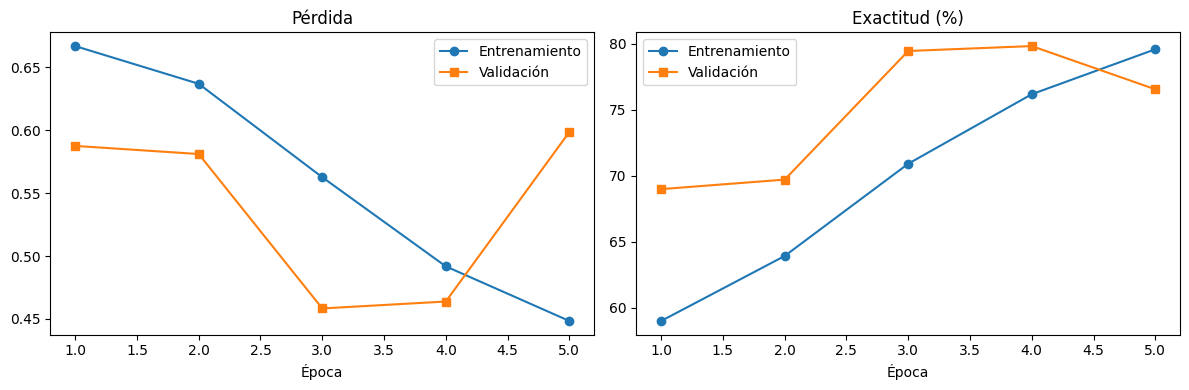

In [37]:
# Curvas de entrenamiento
hist = np.array(historial)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(range(1,N_EPOCHS+1), hist[:,0], 'o-', label='Entrenamiento')
ax[0].plot(range(1,N_EPOCHS+1), hist[:,2], 's-', label='Validación')
ax[0].set_title('Pérdida'); ax[0].set_xlabel('Época'); ax[0].legend()
ax[1].plot(range(1,N_EPOCHS+1), hist[:,1]*100, 'o-', label='Entrenamiento')
ax[1].plot(range(1,N_EPOCHS+1), hist[:,3]*100, 's-', label='Validación')
ax[1].set_title('Exactitud (%)'); ax[1].set_xlabel('Época'); ax[1].legend()
plt.tight_layout(); plt.show()

Exactitud en prueba: 79.50%

Informe de clasificación:
              precision    recall  f1-score   support

    negativa       0.80      0.78      0.79      1998
    positiva       0.79      0.81      0.80      2002

    accuracy                           0.80      4000
   macro avg       0.80      0.79      0.79      4000
weighted avg       0.80      0.80      0.79      4000



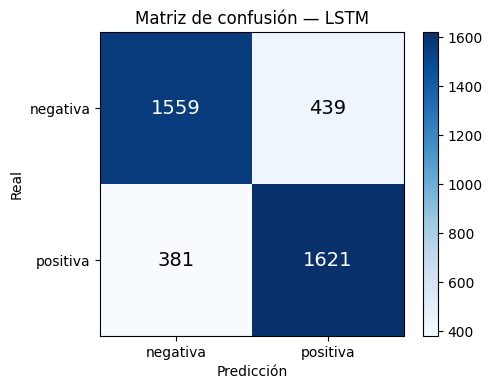

In [38]:
# Métricas finales con el mejor modelo
modelo.load_state_dict(torch.load('mejor_modelo.pt'))
modelo.eval()

y_real, y_pred = [], []
with torch.no_grad():
    for X, L, y in test_loader:
        X = X.to(device)
        pred = torch.round(torch.sigmoid(modelo(X, L).squeeze(1)))
        y_pred.extend(pred.cpu().numpy())
        y_real.extend(y.numpy())

y_real = np.array(y_real); y_pred = np.array(y_pred)
print(f"Exactitud en prueba: {accuracy_score(y_real, y_pred)*100:.2f}%\n")
print("Informe de clasificación:")
print(classification_report(y_real, y_pred, target_names=['negativa','positiva']))

# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xticks([0,1]); ax.set_xticklabels(['negativa','positiva'])
ax.set_yticks([0,1]); ax.set_yticklabels(['negativa','positiva'])
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — LSTM'); plt.colorbar(im); plt.tight_layout(); plt.show()

## 2.7 Inferencia sobre reseñas nuevas

Probamos el modelo con frases escritas manualmente para verificar su comportamiento cualitativo.

In [39]:
def predecir_sentimiento(texto):
    modelo.eval()
    ids, lon = codificar(limpiar_texto(texto))
    X = torch.tensor([ids], dtype=torch.long).to(device)
    L = torch.tensor([lon], dtype=torch.long)
    with torch.no_grad():
        prob = torch.sigmoid(modelo(X, L).squeeze(1)).item()
    etiqueta = 'POSITIVA' if prob >= 0.5 else 'NEGATIVA'
    return etiqueta, prob

ejemplos = [
    "This movie was absolutely brilliant, I loved the acting and the story.",
    "A complete waste of time, boring and poorly directed.",
    "One of the best films I have ever seen, truly moving.",
    "The plot made no sense and I was bored the whole time.",
]
for e in ejemplos:
    etiqueta, prob = predecir_sentimiento(e)
    print(f"[{etiqueta} | p={prob:.2f}]  {e}")

[POSITIVA | p=0.75]  This movie was absolutely brilliant, I loved the acting and the story.
[NEGATIVA | p=0.04]  A complete waste of time, boring and poorly directed.
[POSITIVA | p=0.90]  One of the best films I have ever seen, truly moving.
[NEGATIVA | p=0.06]  The plot made no sense and I was bored the whole time.


# Conclusiones del notebook

- Las **representaciones de frecuencia** (BoW, TF-IDF) son simples y eficaces para clasificación lineal, pero dispersas y sin información semántica ni de orden.
- Las **representaciones distribucionales** (Word2Vec, *Sentence Transformers*) capturan similitud semántica en espacios densos; los *embeddings* contextuales separan mejor el sentimiento incluso sin entrenamiento sobre el corpus.
- La **LSTM bidireccional** sobre secuencias de tokens aprovecha el orden de las palabras y constituye el enfoque correcto de RNN para análisis de sentimiento, mejorando conceptualmente el esquema Doc2Vec → LSTM del *notebook* guía.
- La metodología aplica **buenas prácticas**: semillas fijas, vocabulario construido solo con entrenamiento, *padding* con secuencias empacadas, recorte de gradiente y evaluación con métricas completas.

> Los valores numéricos concretos (exactitud, pérdida, matriz de confusión) se generan al ejecutar este *notebook* en Google Colab. Para el informe en PDF se reportan los resultados obtenidos en la ejecución.